In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

from overseec.modules.semseg import *
from overseec.modules.mask_refiner import *
from overseec.overseec_config import AllConfig
from overseec.OVerSeeC import OVerSeeC

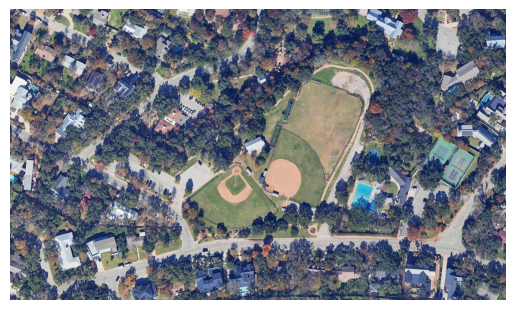

In [107]:
map_name = "austin_baseball"
MR_prefix = "samrefiner"
# prompt_prefix = "prompt_3"
sam_model_prefix = "vit_h"
cuda_device = "cuda:0"
sat_img_path = f"/scratch/rwik/SARA/molmo_testing/geotiffs/tiffs/{map_name}.tif"
sat_img = cv2.imread(sat_img_path)

plt.imshow(sat_img[..., ::-1])
plt.axis("off")
plt.show()

# Cost Function

In [ ]:
def mask_and(mask1: np.ndarray, mask2: np.ndarray) -> np.ndarray:
    return np.logical_and(mask1, mask2).astype(np.uint8)

def mask_or(mask1: np.ndarray, mask2: np.ndarray) -> np.ndarray:
    return np.logical_or(mask1, mask2).astype(np.uint8)

def mask_not(mask: np.ndarray) -> np.ndarray:
    return np.logical_not(mask).astype(np.uint8)

def mask_remove(mask1: np.ndarray, mask2: np.ndarray) -> np.ndarray:
    return (mask1 & ~mask2).astype(np.uint8)


def generate_costmap(mask_dict):
    shape = next(iter(mask_dict.values())).shape

    device = next(iter(mask_dict.values())).device
    road_logit = mask_dict.get('road', torch.zeros(shape, dtype=torch.float32, device=device))
    trees_logit = mask_dict.get('tree', torch.zeros(shape, dtype=torch.float32, device=device))
    buildings_logit = mask_dict.get('building', torch.zeros(shape, dtype=torch.float32, device=device))
    grass_logit = mask_dict.get('grass', torch.zeros(shape, dtype=torch.float32, device=device))
    trail_logit = mask_dict.get('trail or footway', torch.zeros(shape, dtype=torch.float32, device=device))
    water_logit = mask_dict.get('water', torch.zeros(shape, dtype=torch.float32, device=device))
    # river_logit = mask_dict.get('river', torch.zeros(shape, dtype=torch.float32))
    baseball_field_logit = mask_dict.get('baseball field', torch.zeros(shape, dtype=torch.float32, device=device))

    road_mask = road_logit > 0.5
    trail_mask = trail_logit > 0.5
    grass_mask = grass_logit > 0.5  
    buildings_mask = buildings_logit > 0.5
    trees_mask = trees_logit > 0.5
    water_mask = water_logit > 0.5
    baseball_field_mask = baseball_field_logit > 0.5
    

    # Unknown Mask
    mask_count = road_mask.to(torch.float32) + trail_mask.to(torch.float32) + grass_mask.to(torch.float32) + \
                 buildings_mask.to(torch.float32) + trees_mask.to(torch.float32) + water_mask.to(torch.float32) + baseball_field_mask.to(torch.float32)

    data_region = (mask_count > 0)
    data_region_float = data_region.to(torch.float32)

    # Heirarchy
    # grass_mask = mask_remove(grass_mask, baseball_field_mask)
    grass_mask = grass_mask & ~baseball_field_mask
    # Geometry
    # Nothing for now


    costmap = torch.zeros(shape, dtype=torch.float32, device=device)
    costmap[road_mask] += 0 * road_logit[road_mask]
    costmap[trail_mask] += 0 * trail_logit[trail_mask]
    costmap[grass_mask] += 300 * grass_logit[grass_mask]
    costmap[buildings_mask] += 2000 * buildings_logit[buildings_mask]
    costmap[trees_mask] += 2000 * trees_logit[trees_mask]
    costmap[water_mask] += 2000 * water_logit[water_mask]
    costmap[baseball_field_mask] += 2000 * baseball_field_logit[baseball_field_mask]

    costmap[data_region] = costmap[data_region] / mask_count[data_region]

    costmap += costmap.max() * (1 - data_region_float)  # Assign high cost to non-data regions


    return costmap


In [109]:
overseec_clipseg_classes = {
    "road": (128, 64, 128),
    "trail or footway": (244, 35, 232),
    "tree": (0, 128, 0),
    "grass": (0, 128, 128),
    "building": (0, 0, 128),
    "water": (0, 0, 255),
    "baseball field": (107, 142, 35),
}

overseec_clipseg_classes_semseg_knobs = {
    "road": 0.4,
    "trail or footway": 0.4,
    "tree": 0.8,
    "grass": 0.8,
    "building": 0.8,
    "water": 0.8,
    "baseball field": 0.8,
}

semseg_tile_size = (512, 512)
semseg_stride = 256
semseg_tile_combine_method = "max"

mask_refiner_tile_size = (512, 512)
mask_refiner_stride = 256
mask_refiner_tile_combine_method = "mean"


overseec_clipseg_config = AllConfig(
    model_ckpt = "xyz",
    model_name = "clipseg",
    mask_refiner_name= "samrefiner",

    classes=overseec_clipseg_classes,
    classes_semseg_knobs=overseec_clipseg_classes_semseg_knobs,

    semseg_tile_size = semseg_tile_size,
    semseg_stride = semseg_stride,
    semseg_tile_combine_method= semseg_tile_combine_method,

    mask_refiner_tile_size = mask_refiner_tile_size,
    mask_refiner_stride = mask_refiner_stride,
    mask_refiner_tile_combine_method = mask_refiner_tile_combine_method,
    use_negative_points= True,

    sam_model= sam_model_prefix,

    sam_device= cuda_device,
    cmap_device= cuda_device,
    semseg_device= cuda_device,


)

overseec_clipseg_config.reset()

overseec_clipseg = OVerSeeC(
    config=overseec_clipseg_config
)

In [110]:
clipseg_sigmoid_mask_refiner_logits, clipseg_mask_refiner_logits_map, clipseg_mask_refiner_logits_tiled, clipseg_sigmoid_semseg_logits, semseg_logits_map = overseec_clipseg(sat_img_path, sat_img)




Semantic Segmentation ..... 


Cropping Image Patches:   0%|          | 0/180 [00:00<?, ?it/s]

semseg:   0%|          | 0/12 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/scratch/rwik/miniconda3/envs/vllm/lib/python3.10/site-packages/transformers/image_processing_utils.py:44: UserWarning: The following named arguments are not valid for `ViTImageProcessor.preprocess` and were ignored: 'padding', 'truncation'
  return self.preprocess(images, **kwargs)
semseg: 100%|█████████




Mask Refiner ..... 


Mask refiner:   0%|          | 0/180 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PA

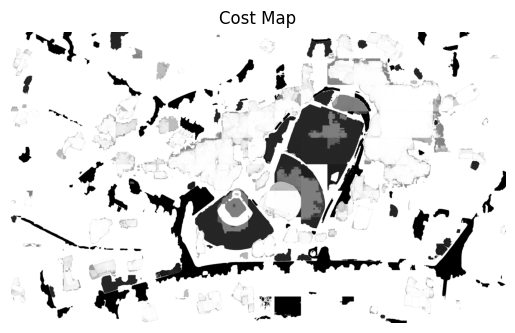

In [111]:
clipseg_MR_general_masks = {}
class_names = list(overseec_clipseg_config.classes.keys())
for idx in range(len(class_names)):
    clipseg_MR_general_masks[class_names[idx]] = clipseg_sigmoid_mask_refiner_logits[idx]

clipseg_costmap = generate_costmap(clipseg_MR_general_masks)
clipseg_costmap = clipseg_costmap.cpu().numpy()
plt.imshow(clipseg_costmap, cmap='gray')
plt.title("Cost Map")
plt.axis('off')
plt.show()

In [112]:
overseec_segformer_classes = {
    "road": (128, 64, 128),
    "tree": (0, 128, 0),
    "grass": (0, 128, 128),
    "building": (0, 0, 128),
    "trail or footway": (244, 35, 232),
    "water": (0, 0, 255),
    # "baseball field": (107, 142, 35),
}

overseec_segformer_classes_semseg_knobs = {
    "road": 0.8,
    "tree": 0.8,
    "grass": 0.8,
    "building": 0.8,
    "trail or footway": 0.8,
    "water": 0.8,
    # "baseball field": 0.6,
}

semseg_tile_size = (512, 512)
semseg_stride = 256
semseg_tile_combine_method = "max"

mask_refiner_tile_size = (512, 512)
mask_refiner_stride = 256
mask_refiner_tile_combine_method = "mean"


overseec_segformer_config = AllConfig(
    model_ckpt = "/scratch/rwik/SARA/molmo_testing/training_scripts/checkpoints/segformer_unified_dataset_new_2/traversability-epoch=84.ckpt",
    model_name = "segformer",
    mask_refiner_name= "samrefiner",

    classes=overseec_segformer_classes,
    classes_semseg_knobs=overseec_segformer_classes_semseg_knobs,

    semseg_tile_size = semseg_tile_size,
    semseg_stride = semseg_stride,
    semseg_tile_combine_method= semseg_tile_combine_method,

    mask_refiner_tile_size = mask_refiner_tile_size,
    mask_refiner_stride = mask_refiner_stride,
    mask_refiner_tile_combine_method = mask_refiner_tile_combine_method,
    use_negative_points= True,

    sam_model= sam_model_prefix,

    sam_device= cuda_device,
    cmap_device= cuda_device,
    semseg_device= cuda_device,
    


)

overseec_segformer_config.reset()

overseec_segformer = OVerSeeC(
    config=overseec_segformer_config
)

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([6]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([6, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [113]:
segformer_sigmoid_mask_refiner_logits, segformer_mask_refiner_logits_map, segformer_mask_refiner_logits_tiled, segformer_sigmoid_semseg_logits, semseg_logits_map = overseec_segformer(sat_img_path, sat_img)




Semantic Segmentation ..... 


semseg:   0%|          | 0/12 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
semseg: 100%|██████████| 12/12 [00:09<00:00,  1.30it/s]





Mask Refiner ..... 


Mask refiner:   0%|          | 0/180 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PA

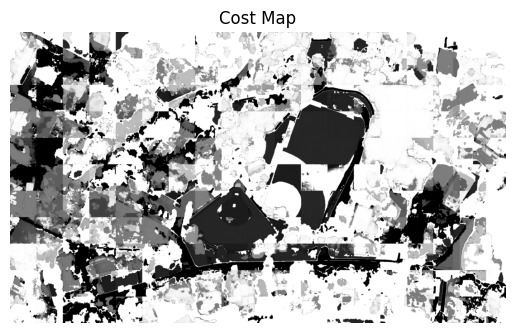

In [114]:
segformer_MR_general_masks = {}
class_names = list(overseec_segformer_config.classes.keys())
for idx in range(len(class_names)):
    segformer_MR_general_masks[class_names[idx]] = segformer_sigmoid_mask_refiner_logits[idx]

segformer_costmap = generate_costmap(segformer_MR_general_masks)
segformer_costmap = segformer_costmap.cpu().numpy()

# print(overseec_segformer_config.semseg_config.default_classes)
plt.imshow(segformer_costmap, cmap='gray')
plt.title("Cost Map")
plt.axis('off')
plt.show()

In [115]:
overseec_dinounet_classes = {
    "road": (128, 64, 128),
    "tree": (0, 128, 0),
    "grass": (0, 128, 128),
    "building": (0, 0, 128),
    "trail or footway": (244, 35, 232),
    "water": (0, 0, 255),
    # "baseball field": (107, 142, 35),
}

overseec_dinounet_classes_semseg_knobs = {
    "road": 0.8,
    "tree": 0.8,
    "grass": 0.8,
    "building": 0.8,
    "trail or footway": 0.8,
    "water": 0.8,
    # "baseball field": 0.6,
}

semseg_tile_size = (512, 512)
semseg_stride = 256
semseg_tile_combine_method = "max"

mask_refiner_tile_size = (512, 512)
mask_refiner_stride = 256
mask_refiner_tile_combine_method = "mean"


overseec_dinounet_config = AllConfig(
    model_ckpt = "/scratch/rwik/SARA/molmo_testing/training_scripts/checkpoints/dinounet_unified_dataset_new_2/traversability-epoch=84.ckpt",
    model_name = "dinounet",
    mask_refiner_name= "samrefiner",

    classes=overseec_dinounet_classes,
    classes_semseg_knobs=overseec_dinounet_classes_semseg_knobs,

    semseg_tile_size = semseg_tile_size,
    semseg_stride = semseg_stride,
    semseg_tile_combine_method= semseg_tile_combine_method,

    mask_refiner_tile_size = mask_refiner_tile_size,
    mask_refiner_stride = mask_refiner_stride,
    mask_refiner_tile_combine_method = mask_refiner_tile_combine_method,
    use_negative_points= True,

    sam_model= sam_model_prefix,

    sam_device= cuda_device,
    cmap_device= cuda_device,
    semseg_device= cuda_device,
    


)

overseec_dinounet_config.reset()

overseec_dinounet = OVerSeeC(
    config=overseec_dinounet_config
)

Using cache found in /home/rwik2000/.cache/torch/hub/facebookresearch_dino_main


In [116]:
dinounet_sigmoid_mask_refiner_logits, dinounet_mask_refiner_logits_map, dinounet_mask_refiner_logits_tiled, dinounet_sigmoid_semseg_logits, dinounet_semseg_logits_map = overseec_dinounet(sat_img_path, sat_img)





Semantic Segmentation ..... 


semseg:   0%|          | 0/12 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
semseg: 100%|██████████| 12/12 [00:44<00:00,  3.69s/it]





Mask Refiner ..... 


Mask refiner:   0%|          | 0/180 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PA

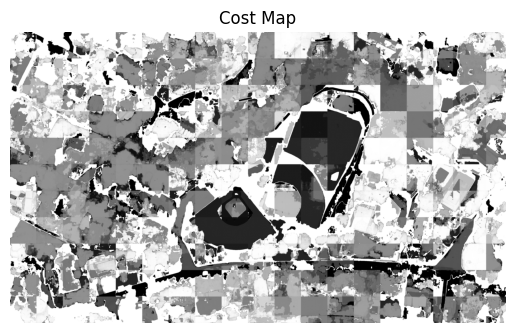

In [117]:
dinounet_MR_general_masks = {}
class_names = list(overseec_dinounet_config.classes.keys())
for idx in range(len(class_names)):
    dinounet_MR_general_masks[class_names[idx]] = dinounet_sigmoid_mask_refiner_logits[idx]

dinounet_costmap = generate_costmap(dinounet_MR_general_masks)
dinounet_costmap = dinounet_costmap.cpu().numpy()

# print(overseec_dinounet_config.semseg_config.default_classes)
plt.imshow(dinounet_costmap, cmap='gray')
plt.title("Cost Map")
plt.axis('off')
plt.show()